#### Run the following only during the first time running the whole jupiter notebook

In [1]:
import os
import sys
current_dir = os.path.dirname(os.getcwd())
if not current_dir in sys.path:
    sys.path.append(current_dir)

# ----------------------------------------------------

In [2]:
import math
import torch
import sequence
import numpy as np
import torchkbnufft as tkbn
import matplotlib.pyplot as plt
from simulate.kernels import cpu_non_selective, cpu_relaxation, cpu_spatial_selective

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

img_size = 256

# values in seconds
t1_wm = 0.8         
t2_wm = 0.08
t1_myelin = 0.226         
t2_myelin = 300 * 1e-6


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


## 1. Create T1 and T2 Maps

In [3]:
# Inner square (pure myelin)
square_size_inner = 80
top_inner = (img_size - square_size_inner) // 2
bottom_inner = (img_size + square_size_inner) // 2

# Mixed square (mixed signals)
square_size_mixed = 180
top_mixed = (img_size - square_size_mixed) // 2
bottom_mixed = (img_size + square_size_mixed) // 2

### (1) White Matter Maps

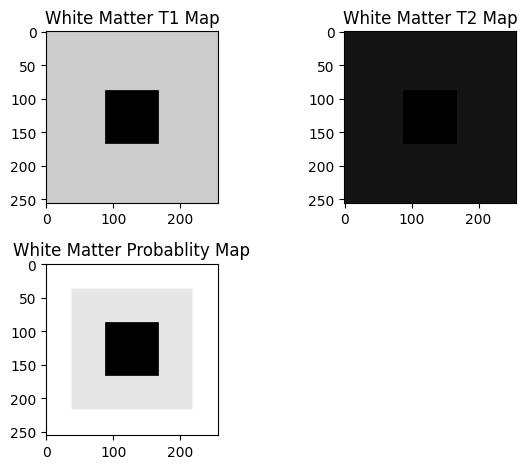

In [4]:
# T1 map
T1_map_wm = np.full([img_size, img_size], t1_wm, dtype=np.float64)
T1_map_wm[top_inner:bottom_inner, top_inner:bottom_inner] = 0

# T2 map
T2_map_wm = np.full([img_size, img_size], t2_wm, dtype=np.float64)
T2_map_wm[top_inner:bottom_inner, top_inner:bottom_inner] = 0

# Probability map
prob_map_wm = np.full([img_size, img_size], 1, dtype=np.float64)
prob_map_wm[top_mixed:bottom_mixed, top_mixed:bottom_mixed] = 0.9
prob_map_wm[top_inner:bottom_inner, top_inner:bottom_inner] = 0


plt.subplot(2,2,1)
plt.imshow(T1_map_wm, cmap='gray', vmin = 0, vmax = 1)
plt.title("White Matter T1 Map")

plt.subplot(2,2,2)
plt.imshow(T2_map_wm, cmap='gray', vmin = 0, vmax = 1)
plt.title("White Matter T2 Map")

plt.subplot(2,2,3)
plt.imshow(prob_map_wm, cmap='gray', vmin = 0, vmax = 1)
plt.title("White Matter Probablity Map")
plt.tight_layout()
plt.show()

### (2) Myelin Maps

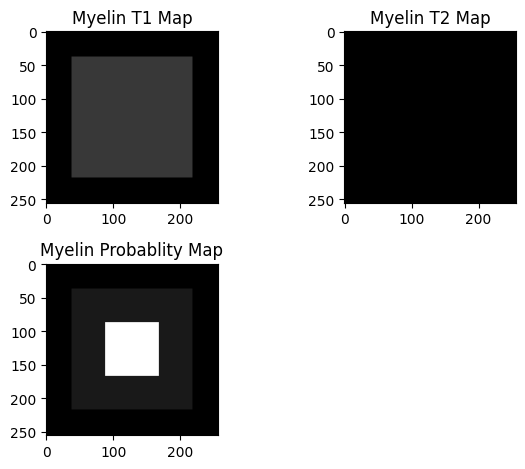

In [81]:
# T1 map
T1_map_myelin = np.full([img_size, img_size], 0, dtype=np.float64)
T1_map_myelin[top_mixed:bottom_mixed, top_mixed:bottom_mixed] = t1_myelin

# # T2 map
T2_map_myelin = np.full([img_size, img_size], 0, dtype=np.float64)
T2_map_myelin[top_mixed:bottom_mixed, top_mixed:bottom_mixed] = t2_myelin

# Probability map
prob_map_myelin = np.full([img_size, img_size], 0, dtype=np.float64)
prob_map_myelin[top_mixed:bottom_mixed, top_mixed:bottom_mixed] = 0.1
prob_map_myelin[top_inner:bottom_inner, top_inner:bottom_inner] = 1


plt.subplot(2,2,1)
plt.imshow(T1_map_myelin, cmap='gray', vmin = 0, vmax = 1)
plt.title("Myelin T1 Map")

plt.subplot(2,2,2)
plt.imshow(T2_map_myelin, cmap='gray', vmin = 0, vmax = 1)
plt.title("Myelin T2 Map")

plt.subplot(2,2,3)
plt.imshow(prob_map_myelin, cmap='gray', vmin = 0, vmax = 1)
plt.title("Myelin Probablity Map")
plt.tight_layout()
plt.show()

## 2. Mxy after 90 degree flip

## 3. Radial Sampling

(256, 810)


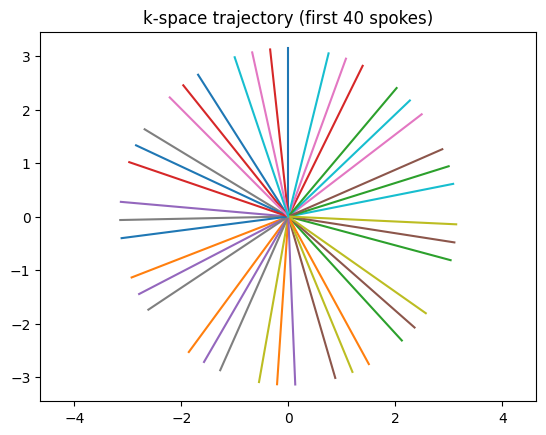

In [35]:
spokelength = img_size
grid_size = (spokelength, spokelength)
nspokes = int(np.ceil(spokelength * math.pi) + 5)

ga = np.deg2rad(180 / ((1 + np.sqrt(5)) / 2))
kx = np.zeros(shape=(spokelength, nspokes))
print(kx.shape)
ky = np.zeros(shape=(spokelength, nspokes))
ky[:, 0] = np.linspace(0, np.pi, spokelength)
for i in range(1, nspokes):
    kx[:, i] = np.cos(ga) * kx[:, i - 1] - np.sin(ga) * ky[:, i - 1]
    ky[:, i] = np.sin(ga) * kx[:, i - 1] + np.cos(ga) * ky[:, i - 1]
    
ky = np.transpose(ky)
kx = np.transpose(kx)

ktraj = np.stack((ky.flatten(), kx.flatten()), axis=0)


# plot the first 40 spokes
plt.plot(kx[:40, :].transpose(), ky[:40, :].transpose())
plt.axis('equal')
plt.title('k-space trajectory (first 40 spokes)')
plt.show()

In [36]:
# convert k-space trajectory to a tensor
ktraj = torch.tensor(ktraj).to(device)
print('ktraj shape: {}'.format(ktraj.shape))

ktraj shape: torch.Size([2, 207360])


In [37]:
# create NUFFT objects, use 'ortho' for orthogonal FFTs
print(grid_size)
nufft_ob = tkbn.KbNufft(
    im_size=(img_size, img_size),
    grid_size=grid_size,
).to(device)
adjnufft_ob = tkbn.KbNufftAdjoint(
    im_size=(img_size, img_size),
    grid_size=grid_size,
).to(device)

print(nufft_ob)
print(adjnufft_ob)

(256, 256)

KbNufft
----------------------------------------
buffers
	tensor: table_0, shape: (6145,)
	tensor: table_1, shape: (6145,)
	tensor: im_size, shape: (2,)
	tensor: grid_size, shape: (2,)
	tensor: n_shift, shape: (2,)
	tensor: numpoints, shape: (2,)
	tensor: offsets, shape: (36, 2)
	tensor: table_oversamp, shape: (2,)
	tensor: order, shape: (2,)
	tensor: alpha, shape: (2,)
	tensor: scaling_coef, shape: (256, 256)


KbNufftAdjoint
----------------------------------------
buffers
	tensor: table_0, shape: (6145,)
	tensor: table_1, shape: (6145,)
	tensor: im_size, shape: (2,)
	tensor: grid_size, shape: (2,)
	tensor: n_shift, shape: (2,)
	tensor: numpoints, shape: (2,)
	tensor: offsets, shape: (36, 2)
	tensor: table_oversamp, shape: (2,)
	tensor: order, shape: (2,)
	tensor: alpha, shape: (2,)
	tensor: scaling_coef, shape: (256, 256)



In [ ]:
prob_map_myelin = torch.as_tensor(prob_map_myelin, device=device)  
prob_map_myelin = prob_map_myelin.to(torch.complex64)             
if prob_map_myelin.ndim == 2:
    prob_map_myelin = prob_map_myelin[None, None, ...]          # add batch/channel dimension

ktraj = torch.as_tensor(ktraj, device=device).to(torch.float64)

print("prob_map_myelin:", prob_map_myelin.shape, prob_map_myelin.dtype, prob_map_myelin.device)
print("ktraj:", ktraj.shape, ktraj.dtype, ktraj.device)


with torch.no_grad():                            # forward (turn off gradient when no need, save memory)
    kdata = nufft_ob(prob_map_myelin, ktraj)


siglevel = torch.abs(kdata).mean()
kdata = kdata + (siglevel/5) * torch.randn(kdata.shape).to(kdata)



prob_map_myelin: torch.Size([1, 1, 256, 256]) torch.complex64 cpu
ktraj: torch.Size([2, 207360]) torch.float64 cpu


(-1481.3044+89.44195j)
(9102.05+1.4679062e-05j)


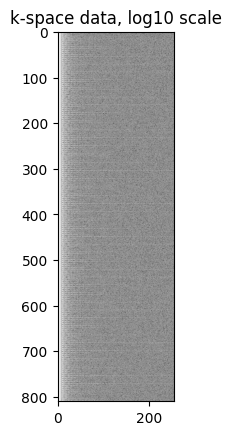

In [ ]:
# plot the k-space data on log-scale
t = np.linspace(0,0.001, spokelength)
kdata_numpy = np.reshape(kdata.cpu().numpy(), (nspokes, spokelength)) * np.exp(-t/t2_myelin)
print(np.min(kdata_numpy))
print(np.max(kdata_numpy))
plt.imshow(np.log10(np.absolute(kdata_numpy)))
plt.gray()
plt.title('k-space data, log10 scale')
plt.show()

In [83]:
# adjnufft back
# method 1: no density compensation (blurry image)
image_blurry = adjnufft_ob(kdata_numpy, ktraj)

# method 2: use density compensation
dcomp = tkbn.calc_density_compensation_function(ktraj=ktraj, im_size=(img_size,img_size))
image_sharp = adjnufft_ob(kdata_numpy * dcomp, ktraj)

AttributeError: 'numpy.ndarray' object has no attribute 'is_complex'

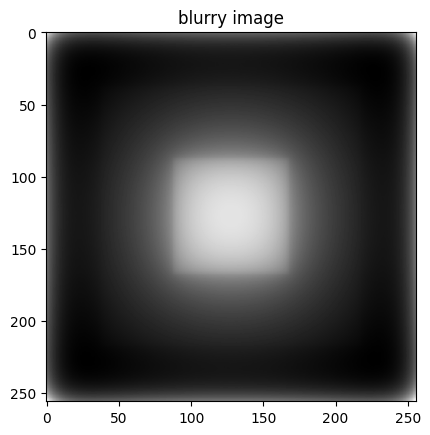

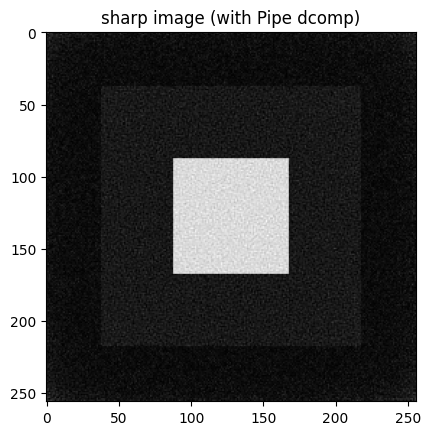

In [14]:
# show the images
image_blurry_numpy = np.squeeze(image_blurry.cpu().numpy())


image_sharp_numpy = np.squeeze(image_sharp.cpu().numpy())

plt.figure(0)
plt.imshow(np.absolute(image_blurry_numpy))
plt.gray()
plt.title('blurry image')

plt.figure(1)
plt.imshow(np.absolute(image_sharp_numpy))
plt.gray()
plt.title('sharp image (with Pipe dcomp)')

plt.show()

In [ ]:
# calculate k-space data
prob_map_myelin = torch.from_numpy(prob_map_myelin).to(torch.complex64)
kdata = nufft_ob(prob_map_myelin, ktraj)
# add some noise (robustness test)
#siglevel = torch.abs(kdata).mean()
#kdata = kdata + (siglevel/5) * torch.randn(kdata.shape).to(kdata)

(256, 256, 200)


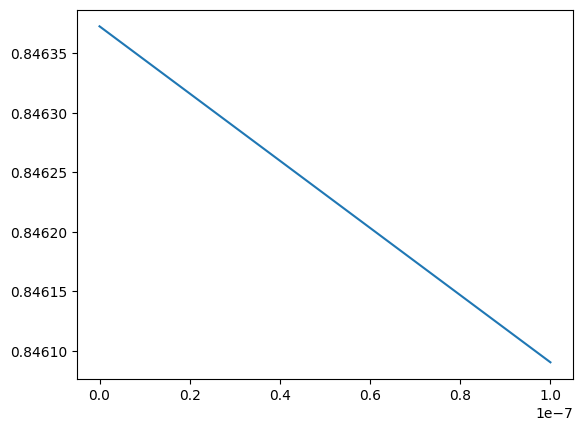

In [ ]:
M0 = prob_map_myelin     
T1 = T1_map_myelin           
T2 = T2_map_myelin          
TI = 0.58                    

duration = np.linspace(0, 0.0000001, 200)  
IR = 1 - 2*np.exp(-TI / (T1 + 1e-12))
decay = np.exp(-duration[None, None, :] / (T2[:, :, None] + 1e-12))
Mxy = (M0 * IR)[:, :, None] * decay

print(Mxy.shape)  # (256, 256, 200)
plt.plot(duration, Mxy[128,128,:])



In [ ]:
duration = np.linspace(0,3,200)
M = np.zeros(len(duration))
for t in duration:      
    M[t] = prob_map_myelin * (1-2*np.exp(-0.58/T1_map_myelin)) * np.exp(t/T2_map_myelin)

TypeError: unsupported operand type(s) for *: 'int' and 'numpy.ufunc'

In [ ]:
# Time Step
dt = 10 # unite: us
non_selective_dt = dt*1e-6
df = np.linspace(-500, 500, 200)

pulse = sequence.rf.hyperbolic_secant(1500, mu=5, bandwidth=2400, dt=dt)
optimal_amplitude = pulse.get_optimal_amplitude(torch.pi)
pulse.amplitude = optimal_amplitude
rf = pulse.waveform
rf = rf.detach().cpu().numpy().astype(np.complex128)
# initial_magnetisation = np.array([0.0, 0.0, 1.0])


# # white matter
# magnetisation_wm_rf = cpu_non_selective(t1_wm, t2_wm, non_selective_dt, df, rf, initial_magnetisation)
# print(magnetisation_wm_rf.shape)

# # myelin
# magnetisation_myelin_rf = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, rf, initial_magnetisation)
# print(magnetisation_myelin_rf.shape)

In [ ]:
img_size = prob_map_myelin.shape[0]
n_steps = len(rf)
Mz_final = np.zeros((img_size, img_size), dtype=np.float64)

for y in range(img_size):
    for x in range(img_size):
        Mz0 = prob_map_myelin[y, x]
        if Mz0 == 0:
            continue

        initial_m = np.zeros(3, dtype=np.float64)
        initial_m[2] = Mz0

        M = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, rf, initial_m)
        print(M.shape)
        Mz_final[y, x] = M  # take final Mz (or use Mx/My as needed)



(200, 152, 3)


ValueError: setting an array element with a sequence.

In [ ]:
n_steps = len(rf)
Mz_final = np.zeros((img_size, img_size), dtype=np.float64)

for y in range(img_size):
    for x in range(img_size):
        Mz0 = prob_map_myelin[y, x]
        if Mz0 == 0:
            continue

        initial_m = np.zeros(3, dtype=np.float64)
        initial_m[2] = Mz0

        M = cpu_non_selective(t1_myelin, t2_myelin, non_selective_dt, df, rf, initial_m)
        Mz_final[y, x] = M[-1, 2]      # take final Mz (or use Mx/My as needed)

